# Mining Process – % Silica Concentrate Prediction

This project aims to develop a **machine learning regression model** to predict the **% Silica Concentrate** in a mining flotation process using operational plant data.  
Accurate prediction of silica concentration is essential to improve process efficiency, reduce laboratory dependency, and support real-time decision-making in the field. The code is divided into five main parts, which are:
1. Imports & Configurations;
2. Dataset Treatment;  
3. Applying Ensemble Model; 
4. Result Analysis;
5. Predicting the Future.


**Responsible:** Paulo Casmal

**Email:** <paulo.casmal@gmail.com>

**Start Date:** 01-31-2026 | **Submission Date:** 


---


## 01 - Imports & Configurations

In [69]:
# import necessary libraries
import locale
import pandas as pd
import numpy as np  
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# import machine learning models to compare performance
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from statsmodels.tsa.arima.model import ARIMA
from sklearn.neural_network import MLPRegressor
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [70]:
# Configuration of matplotlib parameters for consistent styling
mpl.rcParams['figure.figsize'] = (10, 5)  # Default figure size
mpl.rc('lines', lw=2)  # Sets the line width
mpl.rcParams['grid.linewidth'] = 0.5  # Grid line width
mpl.rcParams['grid.linestyle'] = 'dashed'  # Grid line style
mpl.rc(('xtick', 'ytick'), labelsize=15)  # Axis tick label size
mpl.rc('font', family='Arial', size=15)  # Font family and font size
mpl.rcParams['axes.linewidth'] = 0.5 # - Largura das bordas dos gráficos

In [71]:
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8') 
except:
    locale.setlocale(locale.LC_ALL, 'portuguese_brazil')

# 2. Informa ao Matplotlib para usar o separador do locale
mpl.rcParams['axes.formatter.use_locale'] = True

In [72]:
# Load the dataset
path = r'C:\Users\paulo\Downloads\archive (2)\MiningProcess_Flotation_Plant_Database.csv'

df = pd.read_csv(path, decimal=',')

df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


## 02 - Dataset treatment

In [73]:
# Convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [74]:
df.columns

Index(['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='object')

Drop the '% Iron Concentrate' column due to high correlation with target variable. Additionaly, this variable can be measured only at laboratory, which not helps to predict the '% Silica Concentrate' in field.

In [75]:
df = df[['% Iron Concentrate', '% Silica Concentrate']]

In [76]:
df = df.resample("1H").mean()

In [77]:
df = df.drop_duplicates(keep='first')

EDA was performed in a separate script. It does not indicate any major problem with data.

In [78]:
df = df.rename(columns={'% Iron Concentrate': 'Iron_Concentrate', '% Silica Concentrate': 'Silica_Concentrate'})
df = df.drop(columns=['Iron_Concentrate'])

### 2.3 - Lag Features

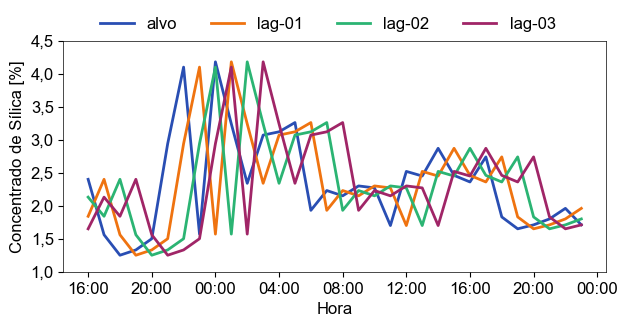

In [79]:
mpl.rc(('xtick', 'ytick'), labelsize=12)  # Axis tick label size
mpl.rc('font', family='Arial', size=12)  # Font family and font size

# Just for visualization purposes
view = df.sort_index().copy()

view = view[view.index > '2017-09-08 00:00:00']

target_col = "Silica_Concentrate"

for lag in range(1, 15):
    view[f"lag-{lag}"] = view[target_col].shift(lag)

view = view.dropna()

fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(view.index, view['Silica_Concentrate'], label='alvo', c='#294EB3')
ax.plot(view.index, view['lag-1'], c='#EF7310', label='lag-01')
ax.plot(view.index, view['lag-2'], c='#2BB473', label='lag-02')
ax.plot(view.index, view['lag-3'], c="#A02567", label='lag-03')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax.legend(ncol=4, loc='upper left', bbox_to_anchor=(0.04, 1.17), frameon=False)
ax.set_ylabel('Concentrado de Sílica [%]')
ax.set_xlabel('Hora')

ax.set_yticks(np.arange(1, 5, 0.5))
fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\lag-features.svg', dpi=140, format='svg', transparent=True)

plt.show()


In [80]:
df = df.sort_index()

target_col = "Silica_Concentrate"

for col in df.columns:
    for lag in range(1, 15):
        df[f"lag-{lag}"] = df[col].shift(lag)

df = df.dropna()

In [81]:
# df = df.drop(columns=['Iron_Concentrate'])

### 2.4 - Cross-Validation

In [82]:
# Using specific time series train test split method
tss = TimeSeriesSplit(n_splits=5, test_size=24*14, gap=24) # 14 days data for testing

df = df.sort_index()

df = df.dropna()

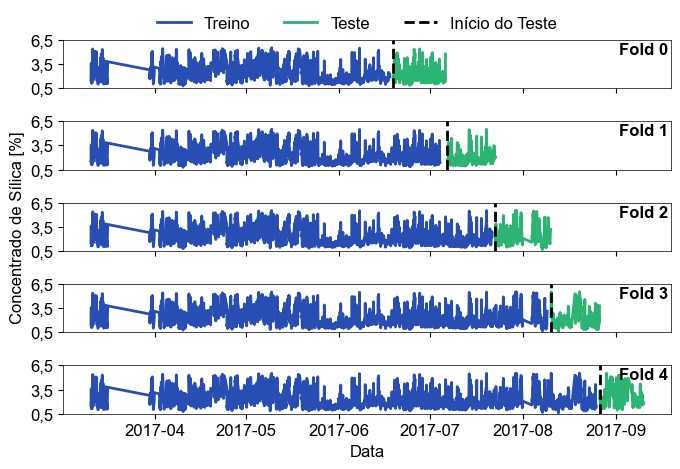

In [83]:
# Just for visualization purposes
fig, axs = plt.subplots(5, 1, figsize=(7, 5), sharex=True)

# Plot each fold
for fold, (train_index, test_index) in enumerate(tss.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    axs[fold].plot(train.index, train['Silica_Concentrate'], label='Treino', c='#294EB3')
    axs[fold].plot(test.index, test['Silica_Concentrate'], label='Teste', c="#2BB473")
    axs[fold].axvline(x=test.index[0], color='k', linestyle='--', label='Início do Teste')

    axs[fold].text(0.915, 0.7, f'Fold {fold}', fontsize=12, transform=axs[fold].transAxes, fontweight='bold')

    axs[fold].set_yticks(np.arange(0.5, 7, 3))
    axs[fold].set_ylim(0.5, 6.5)


axs[2].set_ylabel('Concentrado de Sílica [%]')

axs[0].legend(ncol=3, loc='upper left', bbox_to_anchor=(0.13, 1.8), frameon=False)

plt.xlabel('Data')
plt.tight_layout()

fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\time-series-split.svg', dpi=140, format='svg', transparent=True)

plt.show()

## 03 - Comparing Models

In [84]:
df.columns

Index(['Silica_Concentrate', 'lag-1', 'lag-2', 'lag-3', 'lag-4', 'lag-5',
       'lag-6', 'lag-7', 'lag-8', 'lag-9', 'lag-10', 'lag-11', 'lag-12',
       'lag-13', 'lag-14'],
      dtype='object')

In [85]:
target = 'Silica_Concentrate'
lags_to_test = range(1, 10)

### 3.1 - XGBoost

In [86]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# --- Configurações Iniciais ---
all_results_xgb = [] 
final_best_model_xgb = None # Variável que guardará o "Grande Campeão"
final_best_rmse_global_xgb = np.inf # Para comparação global

# Função auxiliar (caso precise redefinir)
def create_lag_features(data, target_col, n_lags):
    df_lagged = data.copy()
    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged[target_col].shift(i)
    df_lagged.dropna(inplace=True) 
    return df_lagged

# --- Loop Principal ---
for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO XGBOOST: {n_lags} LAGS ")
    print(f"{'='*30}")

    # 1. CRÍTICO: Gerar dataset dinâmico
    df_iter = create_lag_features(df, target, n_lags)
    df_iter = df_iter.reset_index(drop=True)

    fold_metrics = []
    
    # Variáveis para achar o melhor modelo DESTA configuração
    temp_best_model_this_lag = None
    temp_best_rmse_this_lag = np.inf

    # 2. Cross-Validation
    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df_iter)):
        train = df_iter.iloc[train_index]
        test = df_iter.iloc[test_index]

        X_train_full = train.drop(columns=[target])
        y_train_full = train[target]
        X_test = test.drop(columns=[target])
        y_test = test[target]

        # Split validação para Early Stopping (Mantido sua lógica correta: 90/10)
        # Isso garante que o early stopping não veja o X_test
        split_idx = int(len(X_train_full) * 0.9)
        X_train, X_val = X_train_full.iloc[:split_idx], X_train_full.iloc[split_idx:]
        y_train, y_val = y_train_full.iloc[:split_idx], y_train_full.iloc[split_idx:]

        # Instanciando XGBoost
        # early_stopping_rounds no construtor funciona nas versões mais novas do sklearn API
        model_xgb = xgb.XGBRegressor(
            n_estimators=1000,
            learning_rate=0.01,
            max_depth=3,
            objective='reg:squarederror',
            early_stopping_rounds=50, 
            random_state=42,
            n_jobs=-1
        )

        model_xgb.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False 
        )

        y_pred_xgb = model_xgb.predict(X_test)

        # Métricas
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
        r2 = r2_score(y_test, y_pred_xgb)
        mae = mean_absolute_error(y_test, y_pred_xgb)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        # Salva o melhor modelo FÍSICO desta rodada
        if rmse < temp_best_rmse_this_lag:
            temp_best_rmse_this_lag = rmse
            temp_best_model_this_lag = model_xgb

    # 3. Calcular média das métricas deste experimento
    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final XGB ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    # Guardar dados do experimento
    all_results_xgb.append({
        'n_lags_xgb': n_lags,
        'rmse_avg_xgb': avg_rmse,
        'r2_avg_xgb': avg_r2,
        'mae_avg_xgb': avg_mae,
        'best_model_obj_xgb': temp_best_model_this_lag,
        'params_xgb': model_xgb.get_params()
    })

    # --- LÓGICA DO GRANDE CAMPEÃO ---
    if avg_rmse < final_best_rmse_global_xgb:
        final_best_rmse_global_xgb = avg_rmse
        final_best_model_xgb = temp_best_model_this_lag
        best_lags_config_xgb = n_lags

# 4. Rankear Top 3
top_3_xgb = sorted(all_results_xgb, key=lambda x: x['rmse_avg_xgb'])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - XGBOOST")
print("#"*40)
for i, res in enumerate(top_3_xgb):
    print(f"{i+1}º Lugar: {res['n_lags_xgb']} Lags | RMSE Médio: {res['rmse_avg_xgb']:.4f}")

print("\n" + "#"*50)
print(" RESULTADO FINAL - MELHOR MODELO XGB SELECIONADO ")
print("#"*50)
print(f"Melhor Configuração: {best_lags_config_xgb} Lags")
print(f"Menor RMSE Médio Global: {final_best_rmse_global_xgb:.4f}")
print(f"Objeto salvo em 'final_best_model_xgb'")


 TESTANDO XGBOOST: 1 LAGS 
Média Final XGB (1 lags) -> RMSE: 0.7603 | R²: 0.4886

 TESTANDO XGBOOST: 2 LAGS 
Média Final XGB (2 lags) -> RMSE: 0.7561 | R²: 0.4936

 TESTANDO XGBOOST: 3 LAGS 
Média Final XGB (3 lags) -> RMSE: 0.7527 | R²: 0.4985

 TESTANDO XGBOOST: 4 LAGS 
Média Final XGB (4 lags) -> RMSE: 0.7530 | R²: 0.4983

 TESTANDO XGBOOST: 5 LAGS 
Média Final XGB (5 lags) -> RMSE: 0.7559 | R²: 0.4953

 TESTANDO XGBOOST: 6 LAGS 
Média Final XGB (6 lags) -> RMSE: 0.7556 | R²: 0.4958

 TESTANDO XGBOOST: 7 LAGS 
Média Final XGB (7 lags) -> RMSE: 0.7532 | R²: 0.4987

 TESTANDO XGBOOST: 8 LAGS 
Média Final XGB (8 lags) -> RMSE: 0.7549 | R²: 0.4965

 TESTANDO XGBOOST: 9 LAGS 
Média Final XGB (9 lags) -> RMSE: 0.7541 | R²: 0.4976


########################################
      TOP 3 MELHORES - XGBOOST
########################################
1º Lugar: 3 Lags | RMSE Médio: 0.7527
2º Lugar: 4 Lags | RMSE Médio: 0.7530
3º Lugar: 7 Lags | RMSE Médio: 0.7532

################################

### 3.2 - Random Forest

In [87]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# --- Configurações Iniciais ---
all_results_rf = [] # Lista para guardar os resultados de cada configuração
final_best_model_rf = None # Variável que guardará o "Grande Campeão"
final_best_rmse_global_rf = np.inf # Para comparação global

# Função auxiliar para criar lags (caso não tenha sido definida na célula anterior)
def create_lag_features(data, target_col, n_lags):
    df_lagged = data.copy()
    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged[target_col].shift(i)
    df_lagged.dropna(inplace=True) 
    return df_lagged

# --- Início do Loop de Testes ---
for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO RANDOM FOREST: {n_lags} LAGS ")
    print(f"{'='*30}")
    
    # 1. CRÍTICO: Gerar o dataset específico para este n_lags
    df_iter = create_lag_features(df, target, n_lags)
    
    # Resetar índice é vital para o TimeSeriesSplit não falhar nos índices
    df_iter = df_iter.reset_index(drop=True)
    
    fold_metrics = []
    
    # Variáveis para achar o melhor modelo DESTA configuração de lags
    temp_best_model_this_lag = None
    temp_best_rmse_this_lag = np.inf

    # 2. Cross-Validation
    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df_iter)):
        train = df_iter.iloc[train_index]
        test = df_iter.iloc[test_index]

        X_train = train.drop(columns=[target])
        y_train = train[target]
        X_test = test.drop(columns=[target])
        y_test = test[target]

        # Instanciando Random Forest
        model_rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=10, 
            random_state=42,
            n_jobs=-1 
        )

        model_rf.fit(X_train, y_train)

        y_pred_rf = model_rf.predict(X_test)
        
        # Métricas
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
        r2 = r2_score(y_test, y_pred_rf)
        mae = mean_absolute_error(y_test, y_pred_rf)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        # Salva o melhor modelo FÍSICO desta rodada (fold)
        if rmse < temp_best_rmse_this_lag:
            temp_best_rmse_this_lag = rmse
            temp_best_model_this_lag = model_rf

    # Médias desta configuração (n_lags)
    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final RF ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    # Guardar resultados na lista geral
    all_results_rf.append({
        'n_lags_rfs': n_lags,
        'rmse_avg_rfs': avg_rmse,
        'r2_avg_rfs': avg_r2,
        'mae_avg_rfs': avg_mae,
        'model_obj_rfs': temp_best_model_this_lag,
        'params_rfs': model_rf.get_params()
    })

    # --- LÓGICA DO GRANDE CAMPEÃO ---
    # Se o RMSE médio desta configuração for o menor de todos até agora,
    # salvamos este modelo como o vencedor global.
    if avg_rmse < final_best_rmse_global_rf:
        final_best_rmse_global_rf = avg_rmse
        final_best_model_rf = temp_best_model_this_lag
        best_lags_config_rf = n_lags

# --- Rankear Top 3 e Mostrar Vencedor ---
top_3_rf = sorted(all_results_rf, key=lambda x: x['rmse_avg_rfs'])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - RANDOM FOREST")
print("#"*40)
for i, res in enumerate(top_3_rf):
    print(f"{i+1}º Lugar: {res['n_lags_rfs']} Lags | RMSE Médio: {res['rmse_avg_rfs']:.4f}")

print("\n" + "#"*50)
print(" RESULTADO FINAL - MELHOR MODELO RF SELECIONADO ")
print("#"*50)
print(f"Melhor Configuração: {best_lags_config_rf} Lags")
print(f"Menor RMSE Médio Global: {final_best_rmse_global_rf:.4f}")
print(f"Objeto salvo em 'final_best_model_rf'")


 TESTANDO RANDOM FOREST: 1 LAGS 
Média Final RF (1 lags) -> RMSE: 0.7669 | R²: 0.4786

 TESTANDO RANDOM FOREST: 2 LAGS 
Média Final RF (2 lags) -> RMSE: 0.7670 | R²: 0.4785

 TESTANDO RANDOM FOREST: 3 LAGS 
Média Final RF (3 lags) -> RMSE: 0.7624 | R²: 0.4845

 TESTANDO RANDOM FOREST: 4 LAGS 
Média Final RF (4 lags) -> RMSE: 0.7649 | R²: 0.4813

 TESTANDO RANDOM FOREST: 5 LAGS 
Média Final RF (5 lags) -> RMSE: 0.7650 | R²: 0.4827

 TESTANDO RANDOM FOREST: 6 LAGS 
Média Final RF (6 lags) -> RMSE: 0.7659 | R²: 0.4812

 TESTANDO RANDOM FOREST: 7 LAGS 
Média Final RF (7 lags) -> RMSE: 0.7679 | R²: 0.4784

 TESTANDO RANDOM FOREST: 8 LAGS 
Média Final RF (8 lags) -> RMSE: 0.7649 | R²: 0.4825

 TESTANDO RANDOM FOREST: 9 LAGS 
Média Final RF (9 lags) -> RMSE: 0.7661 | R²: 0.4815


########################################
      TOP 3 MELHORES - RANDOM FOREST
########################################
1º Lugar: 3 Lags | RMSE Médio: 0.7624
2º Lugar: 4 Lags | RMSE Médio: 0.7649
3º Lugar: 8 Lags | R

### 3.3 - Multi Layer Perceptron

In [88]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# --- Configurações Iniciais ---
# Supondo que você já tenha 'df', 'target' e 'lags_to_test' definidos
# lags_to_test = [1, 3, 6, 12] (exemplo)

all_results_mlp = [] 
final_best_model_mlp = None # Variável que guardará o "Grande Campeão"
final_best_rmse_global = np.inf # Para comparação global

# Função auxiliar para criar lags corretamente
def create_lag_features(data, target_col, n_lags):
    df_lagged = data.copy()
    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged[target_col].shift(i)
    df_lagged.dropna(inplace=True) 
    return df_lagged

# --- Início do Loop de Testes ---
for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO MLP: {n_lags} LAGS ")
    print(f"{'='*30}")
    
    # 1. Cria o dataset específico para este número de lags
    df_iter = create_lag_features(df, target, n_lags)
    df_iter = df_iter.reset_index(drop=True) # Resetar index para o TimeSeriesSplit funcionar
    
    fold_metrics = []
    
    # Variáveis para achar o melhor modelo DESTA configuração de lags
    temp_best_model_this_lag = None
    temp_best_rmse_this_lag = np.inf

    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df_iter)):
        # Divisão Treino/Teste
        train = df_iter.iloc[train_index]
        test = df_iter.iloc[test_index]

        X_train_raw = train.drop(columns=[target])
        y_train = train[target]
        X_test_raw = test.drop(columns=[target])
        y_test = test[target]

        # Escalonamento (Obrigatório para MLP)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # Modelo MLP
        model_mlp = MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            max_iter=1000,
            early_stopping=False, # Desligado para evitar vazamento aleatório
            alpha=0.001,
            random_state=42
        )

        model_mlp.fit(X_train, y_train)
        y_pred = model_mlp.predict(X_test)

        # Métricas
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        # Lógica: Salva o melhor modelo FÍSICO (objeto) desta configuração de lags
        # (Baseado no menor erro de fold individual)
        if rmse < temp_best_rmse_this_lag:
            temp_best_rmse_this_lag = rmse
            temp_best_model_this_lag = model_mlp

    # Médias desta configuração (n_lags)
    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    
    print(f"Resumo ({n_lags} lags) -> RMSE Médio: {avg_rmse:.4f} | Melhor Fold RMSE: {temp_best_rmse_this_lag:.4f}")

    # Armazena resultados na lista geral
    all_results_mlp.append({
        'n_lags': n_lags,
        'rmse_avg': avg_rmse,
        'r2_avg': avg_r2,
        'best_model_obj': temp_best_model_this_lag # Objeto do melhor fold desta config
    })

    # --- LÓGICA DO GRANDE CAMPEÃO ---
    # Se a Média de RMSE desta configuração for a menor de todas até agora,
    # esta configuração é a vencedora e salvamos o seu melhor modelo.
    if avg_rmse < final_best_rmse_global:
        final_best_rmse_global = avg_rmse
        final_best_model_mlp = temp_best_model_this_lag
        best_lags_config = n_lags

# --- FIM DO PROCESSO ---

print("\n" + "#"*50)
print(" RESULTADO FINAL - MELHOR MODELO SELECIONADO ")
print("#"*50)
print(f"Melhor Configuração: {best_lags_config} Lags")
print(f"Menor RMSE Médio Global: {final_best_rmse_global:.4f}")

# Agora você tem a variável pronta para usar:
# final_best_model_mlp
print(f"Objeto salvo em 'final_best_model_mlp': {final_best_model_mlp}")


 TESTANDO MLP: 1 LAGS 
Resumo (1 lags) -> RMSE Médio: 0.9640 | Melhor Fold RMSE: 0.8885

 TESTANDO MLP: 2 LAGS 
Resumo (2 lags) -> RMSE Médio: 0.9528 | Melhor Fold RMSE: 0.8552

 TESTANDO MLP: 3 LAGS 
Resumo (3 lags) -> RMSE Médio: 0.9869 | Melhor Fold RMSE: 0.8601

 TESTANDO MLP: 4 LAGS 
Resumo (4 lags) -> RMSE Médio: 0.9769 | Melhor Fold RMSE: 0.9180

 TESTANDO MLP: 5 LAGS 
Resumo (5 lags) -> RMSE Médio: 0.9680 | Melhor Fold RMSE: 0.8566

 TESTANDO MLP: 6 LAGS 
Resumo (6 lags) -> RMSE Médio: 0.9535 | Melhor Fold RMSE: 0.8138

 TESTANDO MLP: 7 LAGS 
Resumo (7 lags) -> RMSE Médio: 0.9064 | Melhor Fold RMSE: 0.8312

 TESTANDO MLP: 8 LAGS 
Resumo (8 lags) -> RMSE Médio: 0.9487 | Melhor Fold RMSE: 0.8751

 TESTANDO MLP: 9 LAGS 
Resumo (9 lags) -> RMSE Médio: 0.9491 | Melhor Fold RMSE: 0.8448

##################################################
 RESULTADO FINAL - MELHOR MODELO SELECIONADO 
##################################################
Melhor Configuração: 7 Lags
Menor RMSE Médio Globa

### 3.4 - ARIMAX

In [89]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import warnings

# Suprimir avisos de convergência (comuns em statsmodels)
warnings.filterwarnings("ignore")

# --- 1. PREPARAÇÃO DOS DADOS (LIMPEZA) ---
# O usuário pediu para remover lags e deixar APENAS a variável alvo.
# Criamos uma Series apenas com o alvo.
y_series = df[target].copy()

# Se houver NaNs no início (devido a lags anteriores no df original), removemos
y_series = y_series.dropna()

# --- Configurações do Grid Search ---
p_values = [1, 2, 3, 4] # Parte Auto-Regressiva
q_values = [0, 1, 2]    # Parte de Média Móvel

all_results_arma = []
final_best_model_arma = None 
final_best_rmse_global_arma = np.inf
best_params_global_arma = None

# --- Loop Principal ---
for p in p_values:
    for q in q_values:
        print(f"\n{'='*30}")
        print(f" TESTANDO ARMA(p={p}, q={q}) ")
        print(f"{'='*30}")

        fold_metrics = []
        
        # Variáveis para o melhor modelo DESTA combinação
        temp_best_model_this_config = None
        temp_best_rmse_this_config = np.inf
        
        tss = TimeSeriesSplit(n_splits=5)

        # Iterar sobre as dobras (folds)
        for fold, (train_index, test_index) in enumerate(tss.split(y_series)):
            try:
                # Split Treino/Teste (Apenas Y, sem X)
                y_train = y_series.iloc[train_index]
                y_test = y_series.iloc[test_index]

                # Instancia o ARMA (usando SARIMAX com d=0 e sem exog)
                # trend='c' adiciona uma constante (intercepto), importante para ARMA
                model = SARIMAX(
                    y_train,
                    order=(p, 0, q), 
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                    trend='c' 
                )

                model_fit = model.fit(disp=False)

                # Previsão (Forecast)
                # Como não tem exog, basta dizer quantos passos à frente
                y_pred_arma = model_fit.forecast(steps=len(y_test))

                # Métricas
                rmse = np.sqrt(mean_squared_error(y_test, y_pred_arma))
                r2 = r2_score(y_test, y_pred_arma)
                mae = mean_absolute_error(y_test, y_pred_arma)

                fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

                # Salva o melhor modelo FÍSICO desta rodada (fold)
                if rmse < temp_best_rmse_this_config:
                    temp_best_rmse_this_config = rmse
                    temp_best_model_this_config = model_fit
            
            except Exception as e:
                # Captura erros de Álgebra Linear (LinAlgError) caso não convirja
                continue

        # Se falhou em todos os folds, pula para o próximo p,q
        if len(fold_metrics) == 0:
            print(f"Configuração ARMA({p},{q}) não convergiu.")
            continue

        # Médias desta configuração
        avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
        avg_r2 = np.mean([m['r2'] for m in fold_metrics])
        avg_mae = np.mean([m['mae'] for m in fold_metrics])

        print(f"Média Final ARMA({p},{q}) -> RMSE: {avg_rmse:.4f}")

        all_results_arma.append({
            'p': p,
            'q': q,
            'rmse_avg_arma': avg_rmse,
            'r2_avg_arma': avg_r2,
            'mae_avg_arma': avg_mae,
            'model_obj_arma': temp_best_model_this_config
        })

        # --- LÓGICA DO GRANDE CAMPEÃO ---
        if avg_rmse < final_best_rmse_global_arma:
            final_best_rmse_global_arma = avg_rmse
            final_best_model_arma = temp_best_model_this_config
            best_params_global_arma = (p, q)

# --- Rankear Top 3 ---
if len(all_results_arma) > 0:
    top_3_arma = sorted(all_results_arma, key=lambda x: x['rmse_avg_arma'])[:3]

    print("\n\n" + "#"*40)
    print("      TOP 3 MELHORES - ARMA")
    print("#"*40)
    for i, res in enumerate(top_3_arma):
        print(f"{i+1}º Lugar: p={res['p']}, q={res['q']} | RMSE Médio: {res['rmse_avg_arma']:.4f}")

    print("\n" + "#"*50)
    print(" RESULTADO FINAL - MELHOR MODELO ARMA SELECIONADO ")
    print("#"*50)
    if best_params_global_arma:
        print(f"Melhor Configuração: p={best_params_global_arma[0]}, q={best_params_global_arma[1]}")
    print(f"Menor RMSE Médio Global: {final_best_rmse_global_arma:.4f}")
    print(f"Objeto salvo em 'final_best_model_arma'")
else:
    print("Nenhum modelo ARMA convergiu com sucesso.")


 TESTANDO ARMA(p=1, q=0) 
Média Final ARMA(1,0) -> RMSE: 1.1633

 TESTANDO ARMA(p=1, q=1) 
Média Final ARMA(1,1) -> RMSE: 1.1628

 TESTANDO ARMA(p=1, q=2) 
Média Final ARMA(1,2) -> RMSE: 1.1625

 TESTANDO ARMA(p=2, q=0) 
Média Final ARMA(2,0) -> RMSE: 1.1628

 TESTANDO ARMA(p=2, q=1) 
Média Final ARMA(2,1) -> RMSE: 1.1629

 TESTANDO ARMA(p=2, q=2) 
Média Final ARMA(2,2) -> RMSE: 1.1621

 TESTANDO ARMA(p=3, q=0) 
Média Final ARMA(3,0) -> RMSE: 1.1622

 TESTANDO ARMA(p=3, q=1) 
Média Final ARMA(3,1) -> RMSE: 1.1622

 TESTANDO ARMA(p=3, q=2) 
Média Final ARMA(3,2) -> RMSE: 1.1612

 TESTANDO ARMA(p=4, q=0) 
Média Final ARMA(4,0) -> RMSE: 1.1634

 TESTANDO ARMA(p=4, q=1) 
Média Final ARMA(4,1) -> RMSE: 1.1640

 TESTANDO ARMA(p=4, q=2) 
Média Final ARMA(4,2) -> RMSE: 1.1641


########################################
      TOP 3 MELHORES - ARMA
########################################
1º Lugar: p=3, q=2 | RMSE Médio: 1.1612
2º Lugar: p=2, q=2 | RMSE Médio: 1.1621
3º Lugar: p=3, q=1 | RMSE Mé

### 3.5 - Long-Short Term Memory (LSTM)

In [91]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Imports do TensorFlow/Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Fixar sementes
np.random.seed(42)
tf.random.set_seed(42)

# --- Configurações Iniciais ---
all_results_lstm = []
final_best_model_lstm = None
final_best_rmse_global_lstm = np.inf
best_lags_config_lstm = None

# Função para criar lags
def create_lag_features(data, target_col, n_lags):
    df_lagged = data.copy()
    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged[target_col].shift(i)
    df_lagged.dropna(inplace=True)
    return df_lagged

# --- Loop Principal ---
for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO LSTM: {n_lags} LAGS ")
    print(f"{'='*30}")

    # 1. Gerar dataset dinâmico
    df_iter = create_lag_features(df, target, n_lags)
    df_iter = df_iter.reset_index(drop=True)

    # --- CORREÇÃO: Identificar quais são as colunas de lag ---
    # Isso garante que só vamos pegar as colunas 'lag_1', 'lag_2', etc.
    # e ignorar outras colunas exógenas que existam no df original.
    lag_cols = [f'lag_{i}' for i in range(1, n_lags + 1)]

    fold_metrics = []
    
    # Variáveis para o melhor modelo DESTA configuração
    temp_best_model_this_lag = None
    temp_best_rmse_this_lag = np.inf

    tss = TimeSeriesSplit(n_splits=5)

    for fold, (train_index, test_index) in enumerate(tss.split(df_iter)):
        
        # Divisão dos dados
        train = df_iter.iloc[train_index]
        test = df_iter.iloc[test_index]

        # --- AQUI ESTAVA O ERRO ---
        # Antes: train.drop(columns=[target]) -> Deixava colunas "lixo"
        # Agora: Selecionamos explicitamente apenas as colunas de LAG
        X_train_raw = train[lag_cols] 
        y_train_raw = train[[target]] 
        
        X_test_raw = test[lag_cols]
        y_test_raw = test[[target]]

        # --- ESCALONAMENTO ---
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_train_scaled = scaler_X.fit_transform(X_train_raw)
        y_train_scaled = scaler_y.fit_transform(y_train_raw)
        
        X_test_scaled = scaler_X.transform(X_test_raw)

        # --- RESHAPE PARA 3D [samples, time_steps, features] ---
        # Agora X_train_scaled tem exatamente 'n_lags' colunas, então o reshape funciona.
        # time_steps = n_lags
        # features = 1
        X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], n_lags, 1))
        X_test_3d = X_test_scaled.reshape((X_test_scaled.shape[0], n_lags, 1))

        # Split Validação Manual
        split_val = int(len(X_train_3d) * 0.9)
        
        X_t, X_v = X_train_3d[:split_val], X_train_3d[split_val:]
        y_t, y_v = y_train_scaled[:split_val], y_train_scaled[split_val:]

        # 2. Arquitetura LSTM
        model_lstm = Sequential([
            Input(shape=(n_lags, 1)),
            LSTM(50, activation='tanh', return_sequences=False), 
            Dropout(0.2),
            Dense(1)
        ])
        
        model_lstm.compile(optimizer='adam', loss='mse')

        # 3. Treinamento
        es = EarlyStopping(
            monitor='val_loss', 
            mode='min', 
            patience=10, 
            restore_best_weights=True
        )
        
        model_lstm.fit(
            X_t, y_t,
            epochs=100, 
            batch_size=32,
            validation_data=(X_v, y_v), 
            callbacks=[es],
            verbose=0 
        )

        # 4. Predição
        y_pred_scaled = model_lstm.predict(X_test_3d, verbose=0)
        
        # Desfazer o scale
        y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
        y_test_real = y_test_raw.values 

        # Métricas
        rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
        r2 = r2_score(y_test_real, y_pred_real)
        mae = mean_absolute_error(y_test_real, y_pred_real)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        if rmse < temp_best_rmse_this_lag:
            temp_best_rmse_this_lag = rmse
            temp_best_model_this_lag = model_lstm

    # Média dos folds
    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final LSTM ({n_lags} lags) -> RMSE: {avg_rmse:.4f}")

    all_results_lstm.append({
        'n_lags': n_lags,
        'rmse_avg': avg_rmse,
        'r2_avg': avg_r2,
        'model_obj': temp_best_model_this_lag
    })

    if avg_rmse < final_best_rmse_global_lstm:
        final_best_rmse_global_lstm = avg_rmse
        final_best_model_lstm = temp_best_model_this_lag
        best_lags_config_lstm = n_lags

# --- Resultados Finais ---
top_3_lstm = sorted(all_results_lstm, key=lambda x: x['rmse_avg'])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - LSTM")
print("#"*40)
for i, res in enumerate(top_3_lstm):
    print(f"{i+1}º Lugar: {res['n_lags']} Lags | RMSE Médio: {res['rmse_avg']:.4f}")

print("\n" + "#"*50)
print(" RESULTADO FINAL - MELHOR MODELO LSTM SELECIONADO ")
print("#"*50)
print(f"Melhor Configuração: {best_lags_config_lstm} Lags")
print(f"Menor RMSE Médio Global: {final_best_rmse_global_lstm:.4f}")
print(f"Objeto salvo em 'final_best_model_lstm'")


 TESTANDO LSTM: 1 LAGS 
Média Final LSTM (1 lags) -> RMSE: 0.7451

 TESTANDO LSTM: 2 LAGS 
Média Final LSTM (2 lags) -> RMSE: 0.7243

 TESTANDO LSTM: 3 LAGS 
Média Final LSTM (3 lags) -> RMSE: 0.7227

 TESTANDO LSTM: 4 LAGS 
Média Final LSTM (4 lags) -> RMSE: 0.7344

 TESTANDO LSTM: 5 LAGS 
Média Final LSTM (5 lags) -> RMSE: 0.7369

 TESTANDO LSTM: 6 LAGS 
Média Final LSTM (6 lags) -> RMSE: 0.7439

 TESTANDO LSTM: 7 LAGS 
Média Final LSTM (7 lags) -> RMSE: 0.7415

 TESTANDO LSTM: 8 LAGS 
Média Final LSTM (8 lags) -> RMSE: 0.7494

 TESTANDO LSTM: 9 LAGS 
Média Final LSTM (9 lags) -> RMSE: 0.7425


########################################
      TOP 3 MELHORES - LSTM
########################################
1º Lugar: 3 Lags | RMSE Médio: 0.7227
2º Lugar: 2 Lags | RMSE Médio: 0.7243
3º Lugar: 4 Lags | RMSE Médio: 0.7344

##################################################
 RESULTADO FINAL - MELHOR MODELO LSTM SELECIONADO 
##################################################
Melhor Configuraç

## 04 - Result Analysis

In [93]:
# --- 1. Extraindo XGBoost (Definimos como sufixo _xgb) ---
lags_xgb, rmse_list_xgb, r2_list_xgb = extract_metrics(
    all_results_xgb, 
    'n_lags_xgb', 
    'rmse_avg_xgb', 
    'r2_avg_xgb'
)

# --- 2. Extraindo Random Forest (Definimos como sufixo _rfs) ---
lags_rf, rmse_list_rf, r2_list_rf = extract_metrics(
    all_results_rf, 
    'n_lags_rfs', 
    'rmse_avg_rfs', 
    'r2_avg_rfs'
)

# --- 3. Extraindo MLP (CORREÇÃO AQUI) ---
# No código corrigido do MLP, usamos chaves genéricas sem sufixo
lags_mlp, rmse_list_mlp, r2_list_mlp = extract_metrics(
    all_results_mlp, 
    'n_lags',      # Antes estava 'n_lags_mlps'
    'rmse_avg',    # Antes estava 'rmse_avg_mlps'
    'r2_avg'       # Antes estava 'r2_avg_mlps'
)

# --- 4. Extraindo LSTM (CORREÇÃO AQUI) ---
# No código do LSTM também usamos chaves genéricas
lags_lstm, rmse_list_lstm, r2_list_lstm = extract_metrics(
    all_results_lstm, 
    'n_lags', 
    'rmse_avg', 
    'r2_avg'
)

# --- 5. Extraindo ARMA ---
# (Mantém a lógica anterior pois ARMA tem estrutura diferente)
df_arma = pd.DataFrame(all_results_arma)
# Agrupar por 'p' (que é nosso lag) e pegar o indice do menor RMSE
idx_best_arma = df_arma.groupby('p')['rmse_avg_arma'].idxmin()
best_arma_per_lag = df_arma.loc[idx_best_arma].sort_values(by='p')

lags_arima = best_arma_per_lag['p'].values
rmse_list_arima = best_arma_per_lag['rmse_avg_arma'].values
r2_list_arima = best_arma_per_lag['r2_avg_arma'].values

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define o 'lags' genérico baseado no XGBoost (que tem mais pontos) para configurar o eixo
lags_general = lags_xgb 

fig_all_models_lags, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- PLOT RMSE (TOP) ---
# Note que cada modelo usa SEU PRÓPRIO eixo X (lags_xgb, lags_rf, etc)
# Isso evita o erro de dimensões diferentes.

ax[0].plot(lags_xgb, rmse_list_xgb, label='XGBoost', c='#294EB3', marker='o')
ax[0].plot(lags_rf, rmse_list_rf, label='Random Forest', c='#A02567', marker='s')
ax[0].plot(lags_mlp, rmse_list_mlp, label='MLP', c="#EF7310", marker='^')

# --- CORREÇÃO AQUI ---
# Usamos 'lags_arima' no eixo X, pois ele tem tamanho (4,) igual ao rmse_list_arima
ax[0].plot(lags_arima, rmse_list_arima, label='ARIMA', c='#2BB473', marker='x') 

ax[0].plot(lags_lstm, rmse_list_lstm, label='LSTM', c="k", marker='d')

# --- PLOT R² (BOTTOM) ---
ax[1].plot(lags_xgb, r2_list_xgb, label='XGBoost', c='#294EB3', marker='o')
ax[1].plot(lags_rf, r2_list_rf, label='Random Forest', c='#A02567', marker='s')
ax[1].plot(lags_mlp, r2_list_mlp, label='MLP', c='#EF7310', marker='^')

# --- CORREÇÃO AQUI TAMBÉM ---
ax[1].plot(lags_arima, r2_list_arima, label='ARIMA', c='#2BB473', marker='x')

ax[1].plot(lags_lstm, r2_list_lstm, label='LSTM', c='k', marker='d')

# --- Estilização ---
ax[0].set_ylabel('RMSE (Menor é melhor)', fontsize=12)
ax[1].set_ylabel('R² (Maior é melhor)', fontsize=12)
ax[1].set_xlabel('Number of Lags', fontsize=12)

ax[0].legend(ncol=5,
             loc='upper center',
             bbox_to_anchor=(0.5, 1.15),
             handlelength=1.1,
             columnspacing=1,
             frameon=False)

# Ajuste do eixo X visual
ax[1].set_xticks(lags_general) 
ax[1].set_xlim(min(lags_general) - 0.5, max(lags_general) + 0.5)

ax[0].grid(lw=0.3, linestyle='--') 
ax[1].grid(lw=0.3, linestyle='--') 

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3980052717.py, line 53)

In [ ]:
metrics_df = pd.DataFrame({
    'n_lags': lags,
    'rmse_xgb': [round(x, 2) for x in rmse_list_xgb],
    'r2_xgb': [round(x, 2) for x in r2_list_xgb],
    'rmse_rf': [round(x, 2) for x in rmse_list_rf],
    'r2_rf': [round(x, 2) for x in r2_list_rf],
    'rmse_mlp': [round(x, 2) for x in rmse_list_mlp],
    'r2_mlp': [round(x, 2) for x in r2_list_mlp],
    'rmse_arima': [round(x, 2) for x in rmse_list_arima],
    'r2_arima': [round(x, 2) for x in r2_list_arima],
    'rmse_lstm': [round(x, 2) for x in rmse_list_lstm],
    'r2_lstm': [round(x, 2) for x in r2_list_lstm]
})

In [ ]:
metrics_df

,n_lags,rmse_xgb,r2_xgb,rmse_rf,r2_rf,rmse_mlp,r2_mlp,rmse_arima,r2_arima,rmse_lstm,r2_lstm
0,1,0.76,0.49,0.76,0.48,0.76,0.48,0.77,0.47,0.74,0.52
1,2,0.76,0.49,0.76,0.48,0.76,0.48,0.89,0.28,0.72,0.54
2,3,0.76,0.49,0.76,0.48,0.76,0.48,0.83,0.39,0.72,0.54
3,4,0.76,0.49,0.76,0.48,0.76,0.48,0.83,0.38,0.72,0.53
4,5,0.76,0.49,0.76,0.48,0.76,0.48,0.81,0.41,0.72,0.54
5,6,0.76,0.49,0.76,0.48,0.76,0.48,0.77,0.47,0.73,0.53
6,7,0.76,0.49,0.76,0.48,0.76,0.48,0.78,0.46,0.73,0.53
7,8,0.76,0.49,0.76,0.48,0.76,0.48,0.76,0.49,0.74,0.52
8,9,0.76,0.49,0.76,0.48,0.76,0.48,0.79,0.44,0.74,0.51


In [ ]:
metrics_df = metrics_df.set_index('n_lags')

In [ ]:
metrics_df_r2 = metrics_df.filter(like='r2').copy()
metrics_df_rmse = metrics_df.filter(like='rmse').copy()

In [ ]:
metrics_df_r2.T

n_lags,1,2,3,4,5,6,7,8,9
r2_xgb,0.49,0.49,0.49,0.49,0.49,0.49,0.49,0.49,0.49
r2_rf,0.48,0.48,0.48,0.48,0.48,0.48,0.48,0.48,0.48
r2_mlp,0.48,0.48,0.48,0.48,0.48,0.48,0.48,0.48,0.48
r2_arima,0.47,0.28,0.39,0.38,0.41,0.47,0.46,0.49,0.44
r2_lstm,0.52,0.54,0.54,0.53,0.54,0.53,0.53,0.52,0.51


In [ ]:
metrics_df_rmse.T

n_lags,1,2,3,4,5,6,7,8,9
rmse_xgb,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76
rmse_rf,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76
rmse_mlp,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76
rmse_arima,0.77,0.89,0.83,0.83,0.81,0.77,0.78,0.76,0.79
rmse_lstm,0.74,0.72,0.72,0.72,0.72,0.73,0.73,0.74,0.74


### 4.1 - Ploting Model Results

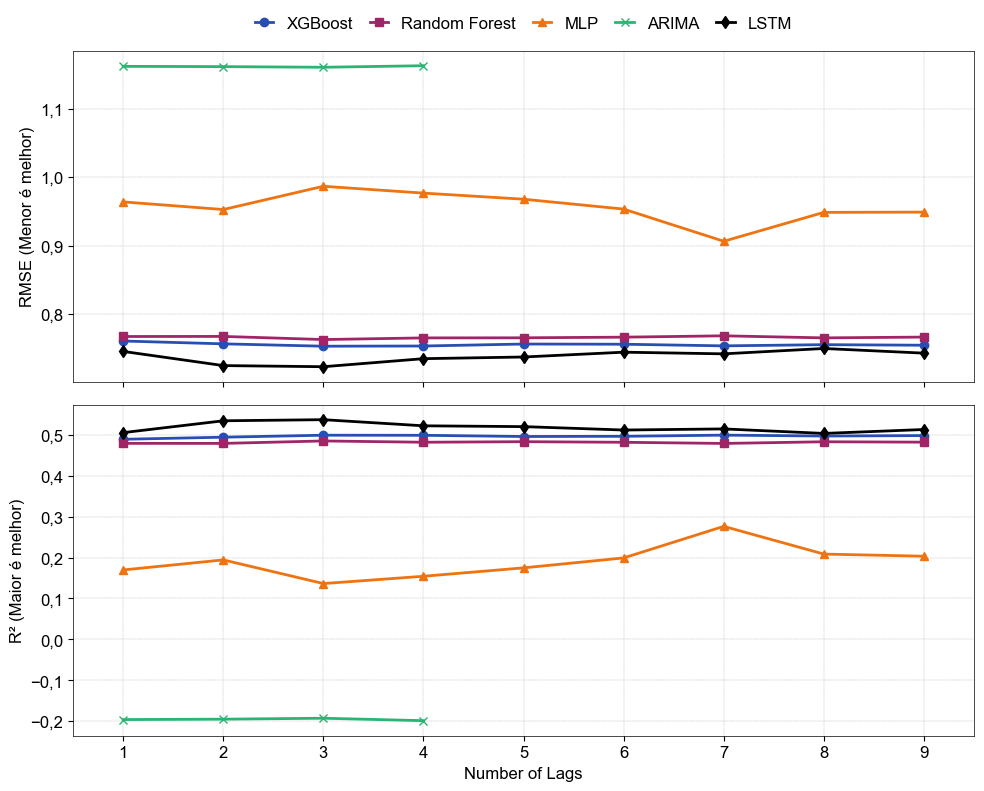

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# Define o 'lags' genérico baseado no XGBoost (que tem mais pontos) para configurar o eixo
lags_general = lags_xgb 

fig_all_models_lags, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- PLOT RMSE (TOP) ---
# Note que cada modelo usa SEU PRÓPRIO eixo X (lags_xgb, lags_rf, etc)
# Isso evita o erro de dimensões diferentes.

ax[0].plot(lags_xgb, rmse_list_xgb, label='XGBoost', c='#294EB3', marker='o')
ax[0].plot(lags_rf, rmse_list_rf, label='Random Forest', c='#A02567', marker='s')
ax[0].plot(lags_mlp, rmse_list_mlp, label='MLP', c="#EF7310", marker='^')

# --- CORREÇÃO AQUI ---
# Usamos 'lags_arima' no eixo X, pois ele tem tamanho (4,) igual ao rmse_list_arima
ax[0].plot(lags_arima, rmse_list_arima, label='ARIMA', c='#2BB473', marker='x') 

ax[0].plot(lags_lstm, rmse_list_lstm, label='LSTM', c="k", marker='d')

# --- PLOT R² (BOTTOM) ---
ax[1].plot(lags_xgb, r2_list_xgb, label='XGBoost', c='#294EB3', marker='o')
ax[1].plot(lags_rf, r2_list_rf, label='Random Forest', c='#A02567', marker='s')
ax[1].plot(lags_mlp, r2_list_mlp, label='MLP', c='#EF7310', marker='^')

# --- CORREÇÃO AQUI TAMBÉM ---
ax[1].plot(lags_arima, r2_list_arima, label='ARIMA', c='#2BB473', marker='x')

ax[1].plot(lags_lstm, r2_list_lstm, label='LSTM', c='k', marker='d')

# --- Estilização ---
ax[0].set_ylabel('RMSE (Menor é melhor)', fontsize=12)
ax[1].set_ylabel('R² (Maior é melhor)', fontsize=12)
ax[1].set_xlabel('Number of Lags', fontsize=12)

ax[0].legend(ncol=5,
             loc='upper center',
             bbox_to_anchor=(0.5, 1.15),
             handlelength=1.1,
             columnspacing=1,
             frameon=False)

# Ajuste do eixo X visual
ax[1].set_xticks(lags_general) 
ax[1].set_xlim(min(lags_general) - 0.5, max(lags_general) + 0.5)

ax[0].grid(lw=0.3, linestyle='--') 
ax[1].grid(lw=0.3, linestyle='--') 

plt.tight_layout()
plt.show()

In [ ]:
# train_rmse = results['validation_0']['rmse']
# val_rmse   = results['validation_1']['rmse']

# fig_error, ax = plt.subplots(figsize=(6, 5))

# ax.plot(train_rmse, label='Train RMSE', c='#0B1741')
# ax.plot(val_rmse, label='Validation RMSE', c='#FF5733')

# ax.set_xlabel('Iteration')
# ax.set_ylabel('RMSE')
# ax.set_title('XGBoost Training vs Validation')
# ax.legend()

# ax.grid(True)
# ax.set_xlim(0, 800)

# # fig_error.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\fm_sc_errors_02.svg', dpi=140, format='svg', transparent=True)

# plt.show()

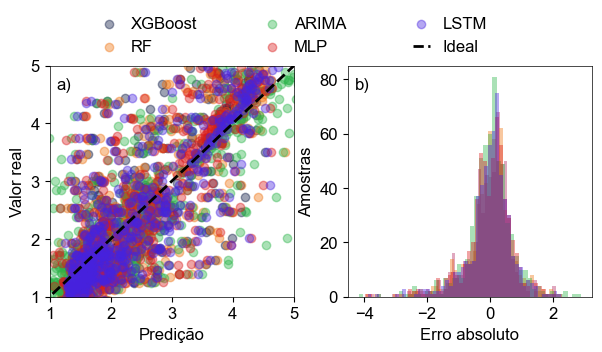

In [ ]:
mpl.rc(('xtick', 'ytick'), labelsize=12)  # Axis tick label size
mpl.rc('font', family='Arial', size=12)  # Font family and font size

fig, ax = plt.subplots(1, 2, figsize=(7, 3))

fig.subplots_adjust(wspace=0.22)

alp = 0.4

ax[0].scatter(y_pred_xgb, y_test_xgb, c='#0B1741', alpha=alp, label='XGBoost')
ax[0].scatter(y_pred_rf, y_test_rf, c='#EF7310', alpha=alp, label='RF')
ax[0].scatter(y_pred_arima, y_test_arima, c='#2BB449', alpha=alp, label='ARIMA')
ax[0].scatter(y_pred_mlps, y_test_mlps, c='#DA1C1C', alpha=alp, label='MLP')
ax[0].scatter(y_pred_lstm, y_test_lstm, c='#4623DF', alpha=alp, label='LSTM')

ax[0].plot([0, 5], [0, 5], color='#000000', ls='--', label='Ideal')

ax[0].set_xlabel('Predição')
ax[0].set_ylabel('Valor real')

ax[0].set_ylim(1, 5)
ax[0].set_xlim(1, 5)



res_arima = np.asarray(y_pred_arima) - np.asarray(y_test_arima)

ax[1].hist(y_pred_xgb - y_test_xgb, bins=50, color='#B2275F', alpha=alp, label='XGBoost')
ax[1].hist(y_pred_rf - y_test_rf, bins=50, color='#EF7310', alpha=alp, label='RF')
ax[1].hist(res_arima, bins=50, color='#2BB449', alpha=alp, label='ARIMA')
ax[1].hist(y_pred_mlps - y_test_mlps, bins=50, color='#DA1C1C', alpha=alp, label='MLP')
ax[1].hist(y_pred_lstm - y_test_lstm, bins=50, color='#4623DF', alpha=alp, label='LSTM')

ax[1].set_xlabel('Erro absoluto')
ax[1].set_ylabel('Amostras')

# ax[0].set_title('a)', pad=60)
# ax[1].set_title('b)', pad=60)

ax[0].text(0.03, 0.95, 'a)', transform=ax[0].transAxes, fontsize=12, va='top')
ax[1].text(0.03, 0.95, 'b)', transform=ax[1].transAxes, fontsize=12, va='top')

ax[0].legend(
            ncol=3,
             loc='upper center',
             bbox_to_anchor=(1, 1.28),
             handlelength=1,
             columnspacing=4,
             frameon=False
             )

fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\res-models-comparinson-errors.svg', dpi=140, format='svg', transparent=True)

plt.show()


# 05 - Predicting the Future

In [ ]:
future = 24 * 2

# índice temporal (use o do y_test correspondente)
idx_future = y_test_xgb.iloc[-future:].index

# colunas (use as do seu DataFrame tabular)
cols_tabular = X_test_xgb.columns

# garante que MLP está em DataFrame
if not hasattr(X_test_mlps, "iloc"):
    X_test_mlps = pd.DataFrame(X_test_mlps, columns=cols_tabular, index=y_test_mlps.index)

X_test_future_xgb = X_test_xgb.iloc[-future:].copy()
X_test_future_rf  = X_test_rf.iloc[-future:].copy()
X_test_future_mlp = X_test_mlps.iloc[-future:].copy()


In [ ]:
import numpy as np

def recursive_forecast_tabular(model, X_seed: pd.DataFrame, horizon: int, lag_cols=None):
    Xf = X_seed.copy(deep=True)

    if lag_cols is None:
        lag_cols = [c for c in Xf.columns if str(c).startswith("lag-")]
        lag_cols = sorted(lag_cols, key=lambda x: int(str(x).split("-")[1]))  # lag-1, lag-2, ...

    preds = np.zeros(horizon, dtype=float)

    for i in range(horizon):
        yhat = model.predict(Xf.iloc[[i]])
        yhat = float(np.ravel(yhat)[0])
        preds[i] = yhat

        if i < horizon - 1:
            # shift lags na próxima linha
            for j in range(len(lag_cols) - 1, 0, -1):
                Xf.loc[Xf.index[i+1], lag_cols[j]] = Xf.loc[Xf.index[i], lag_cols[j-1]]
            Xf.loc[Xf.index[i+1], lag_cols[0]] = yhat

    return preds


In [ ]:
pred_future_xgb = recursive_forecast_tabular(model_xgb, X_test_future_xgb, future)
pred_future_rf  = recursive_forecast_tabular(model_rf,  X_test_future_rf,  future)
pred_future_mlp = recursive_forecast_tabular(model_mlp, X_test_future_mlp, future)


c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(
c:\Users\paulo\AppData\Local\P

In [ ]:
type(model_arima)



statsmodels.tsa.statespace.sarimax.SARIMAX

In [ ]:
pred_future_arima = np.asarray(model_arima.predict(n_periods=future), dtype=float)


TypeError: predict() missing 1 required positional argument: 'params'

In [ ]:
pred_future_lstm = model_lstm.predict(X_test_lstm[-future:])
pred_future_lstm = np.ravel(pred_future_lstm).astype(float)


In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

y_true_future = y_test_xgb.iloc[-future:].copy()
idx = y_true_future.index

fig_fut, ax = plt.subplots(figsize=(10, 5))

ax.plot(idx, y_true_future.values, c="#0B1741", label="Target", linewidth=2)

ax.plot(idx, pred_future_xgb,  c="#FF5733", label="XGBoost", marker="o", alpha=0.8)
ax.plot(idx, pred_future_rf,   c="#EF7310", label="RF",      marker="o", alpha=0.8)
ax.plot(idx, pred_future_arima,c="#2BB449", label="ARIMA",   marker="o", alpha=0.8)
ax.plot(idx, pred_future_mlp,  c="#DA1C1C", label="MLP",     marker="o", alpha=0.8)
ax.plot(idx, pred_future_lstm, c="#4623DF", label="LSTM",    marker="o", alpha=0.8)

ax.set_ylabel("Silica Concentrate [%]")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.legend()
plt.show()


In [ ]:
# import matplotlib.dates as mdates
# import matplotlib.pyplot as plt

# idx = y_true_future.index  # índice de datas do seu teste

# fig_fut, ax = plt.subplots(figsize=(10, 5))

# ax.plot(idx, y_true_future.values, label="Target", color="#0B1741", linewidth=2)

# ax.plot(idx, pred_xgb, label="XGBoost", color="#FF5733", marker="o", alpha=0.8)
# ax.plot(idx, pred_rf,  label="RF",      color="#EF7310", marker="o", alpha=0.8)
# ax.plot(idx, pred_mlp, label="MLP",     color="#DA1C1C", marker="o", alpha=0.8)

# ax.set_ylabel("Silica Concentrate [%]")
# ax.set_xlabel("Date")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
# ax.legend()
# plt.show()


In [ ]:
future = 24 * 2 # in hours (1 day)

X_test_future_xgb = X_test_xgb.iloc[-future:]
X_test_future_rf = X_test_rf.iloc[-future:]
X_test_future_arima = X_test_arima.iloc[-future:]
X_test_future_mlp = X_test_mlps[-future:]
X_test_future_lstm = X_test_lstm[-future:]

In [ ]:
for i in range(future):
    if i == 0:
        y_pred_future_xgb = model_xgb.predict(X_test_future_xgb.iloc[[i]])
        y_pred_future_rf = model_rf.predict(X_test_future_rf.iloc[[i]])
        y_pred_future_arima = model_arima.predict(X_test_future_arima.iloc[[i]])
        y_pred_future_mlp = model_mlp.predict(X_test_future_mlp.iloc[[i]])
        y_pred_future_lstm = model_lstm.predict(X_test_future_lstm.iloc[[i]])
    else:
        X_test_future_xgb.iloc[[i], 0] = y_pred_future_xgb
        X_test_future_rf.iloc[[i], 0] = y_pred_future_rf
        X_test_future_arima.iloc[[i], 0] = y_pred_future_arima
        X_test_future_mlp.iloc[[i], 0] = y_pred_future_mlp
        X_test_future_lstm.iloc[[i], 0] = y_pred_future_lstm
        
        print(y_pred_future_xgb, y_pred_future_rf, y_pred_future_arima, y_pred_future_mlp, y_pred_future_lstm)
        for j in range(1, X_test_future_xgb.shape[1] - 1):
            X_test_future_xgb.iloc[[i], j] = X_test_future_xgb.iloc[[i], j + 1]
            X_test_future_rf.iloc[[i], j] = X_test_future_rf.iloc[[i], j + 1]
            X_test_future_arima.iloc[[i], j] = X_test_future_arima.iloc[[i], j + 1]
            X_test_future_mlp.iloc[[i], j] = X_test_future_mlp.iloc[[i], j + 1]
            X_test_future_lstm.iloc[[i], j] = X_test_future_lstm.iloc[[i], j + 1]

        
        y_pred_future_xgb = model_xgb.predict(X_test_future_xgb.iloc[[i]])
        y_pred_future_rf = model_rf.predict(X_test_future_rf.iloc[[i]])
        y_pred_future_arima = model_arima.predict(X_test_future_arima.iloc[[i]])
        y_pred_future_mlp = model_mlp.predict(X_test_future_mlp.iloc[[i]])
        y_pred_future_lstm = model_lstm.predict(X_test_future_lstm.iloc[[i]])

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
y_test_future_xgb = y_test_xgb.iloc[-future:].copy()
y_test_future_rf = y_test_rf.iloc[-future:].copy()
y_test_future_arima = y_test_arima.iloc[-future:].copy()
y_test_future_mlp = y_test_mlps.iloc[-future:].copy()
y_test_future_lstm = y_test_lstm.iloc[-future:].copy()

In [ ]:
X_test_future.head()

,lag-1,lag-2,lag-3,lag-4,lag-5,lag-6,lag-7,lag-8,lag-9,lag-10,lag-11,lag-12,lag-13,lag-14
date,,,,,,,,,,,,,,
2017-09-07 22:00:00,1.440000,1.72,2.05,1.90,2.15,1.98,2.46,2.66,2.47,2.23,1.85,1.57,1.54,1.49
2017-09-08 00:00:00,1.751586,1.72,2.05,1.90,2.15,1.98,2.46,2.66,2.47,2.23,1.85,1.57,1.54,1.54
2017-09-08 01:00:00,1.836535,1.44,1.72,2.05,1.90,2.15,1.98,2.46,2.66,2.47,2.23,1.85,1.57,1.57
2017-09-08 02:00:00,1.910831,1.36,1.44,1.72,2.05,1.90,2.15,1.98,2.46,2.66,2.47,2.23,1.85,1.85
2017-09-08 03:00:00,1.963948,1.26,1.36,1.44,1.72,2.05,1.90,2.15,1.98,2.46,2.66,2.47,2.23,2.23


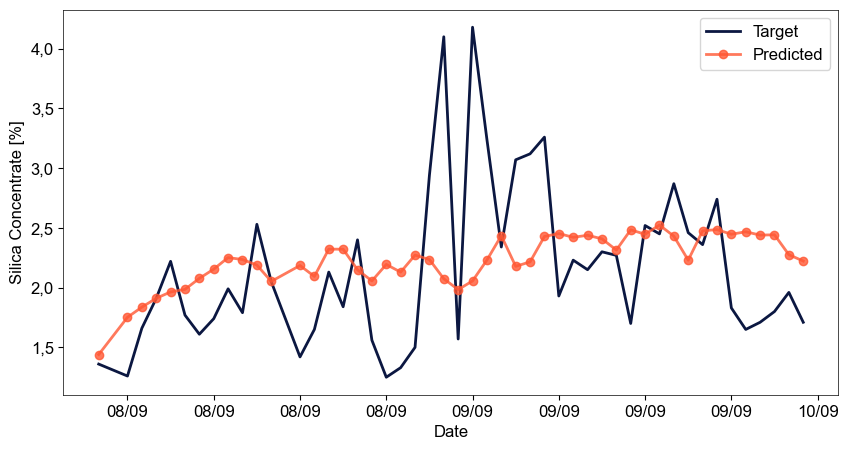

In [ ]:
fig_fut, ax = plt.subplots(figsize=(10, 5))

ax.plot(y_test_future, c='#0B1741', label='Target')
ax.plot(X_test_future.index, X_test_future['lag-1'], c='#FF5733', label='Predicted', marker='o', alpha=0.8)

ax.set_ylabel('Silica Concentrate [%]')
ax.set_xlabel('Date')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

ax.legend()

# fig_fut.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\future-predict.svg', dpi=140, format='svg', transparent=True)

plt.show()

The chart demonstrates that the model is capable of predicting up to a 3-hour horizon with relative low errors.

---